In [1]:
include("./Interpolation.jl")
using .Interpolation
using StatsKit, Pipe, CairoMakie, LinearAlgebra, SwarmMakie
Makie.convert_arguments(::Type{<:AbstractPlot}, x::DataFrame) = ([Point2f(i) for i in Matrix(select(x, [:x, :y])) |> eachrow],)
Makie.convert_arguments(::Type{<:AbstractPlot}, df::DataFrame, col::Vector{Symbol}) = 
    (map(Point2f, select(df, col) |> Matrix |> eachrow),)

Base.rad2deg(x::Missing) = missing
subjs_type_df = CSV.File("./subjs_type.csv") |> DataFrame;

In [2]:
function read2dfs(subj, p2csvs)
    dfs = []
    for csv in p2csvs[subj]
        df = CSV.read(csv, DataFrame)
        push!(dfs, df)
    end
    return dfs
end

read2dfs (generic function with 1 method)

In [3]:
subjs = []
p2csvs = Dict{String, Vector{String}}()
for (root, dir, files) in walkdir("./final_results")
    if occursin("csvs", root)
        push!(subjs, split(root, "/")[end-1])
        push!(p2csvs, split(root, "/")[end-1] => [joinpath(root,f) for f in files if occursin(".csv", f)])
    end
end
# p2csvs

In [4]:
after_cal_df = Dict{String, Vector{DataFrame}}()

Threads.@threads for subj in subjs
    all_dfs = read2dfs(subj, p2csvs)
    tmp_dfs = []
    for df in all_dfs
        # println(df)
        interpolation_df = interpolation_missing_frame(df)
    new_merge_df = @pipe df |> filter(:frames => x -> (x > 300) && (x%20 == 1)) |>
        vcat(_,interpolation_df) |> sort(_,:frames) 

    @pipe new_merge_df |> 
        transform!(_, [:x,:y] => ((x,y) -> @pipe ([[missing;diff(x)]  [missing;diff(y)]] |> eachrow )) => :velocity) |> 
        transform!(_, :velocity => ByRow(norm) => :speed) 

    tmp_cos =  @pipe sum((@pipe new_merge_df.velocity[1:end-1]|>hcat(_...)') .* (@pipe new_merge_df.velocity[2:end]|>hcat(_...)'),dims=2) ./
        (new_merge_df.speed[1:end-1] .* new_merge_df.speed[2:end])

        
    new_merge_df[!, :angle_deg] = acosd.([missing; [(ismissing(i)) ? missing : i > 1 ? i ≈ 1 ? 1 : missing : i for i in tmp_cos]] |> vec)
    # print(angle_deg_df)


    push!(tmp_dfs, new_merge_df)
    end
    after_cal_df[subj] = tmp_dfs
end

In [5]:
new_df = DataFrame(:data => String[], :dfs => DataFrame[])

for (subj, dfs) in after_cal_df
    for df in dfs
        push!(new_df, (subj, df))
    end
end
leftjoin!(new_df, subjs_type_df, on = :data => :subjs)
transform!(new_df, :dfs => ByRow(x -> size(x,1)) => :frames_num)
transform!(new_df, :dfs => ByRow(x -> x.speed |> skipmissing |> collect |> mean) => :mean_speed);


In [6]:
figs = vis_trace.(read2dfs(subjs[6], p2csvs));

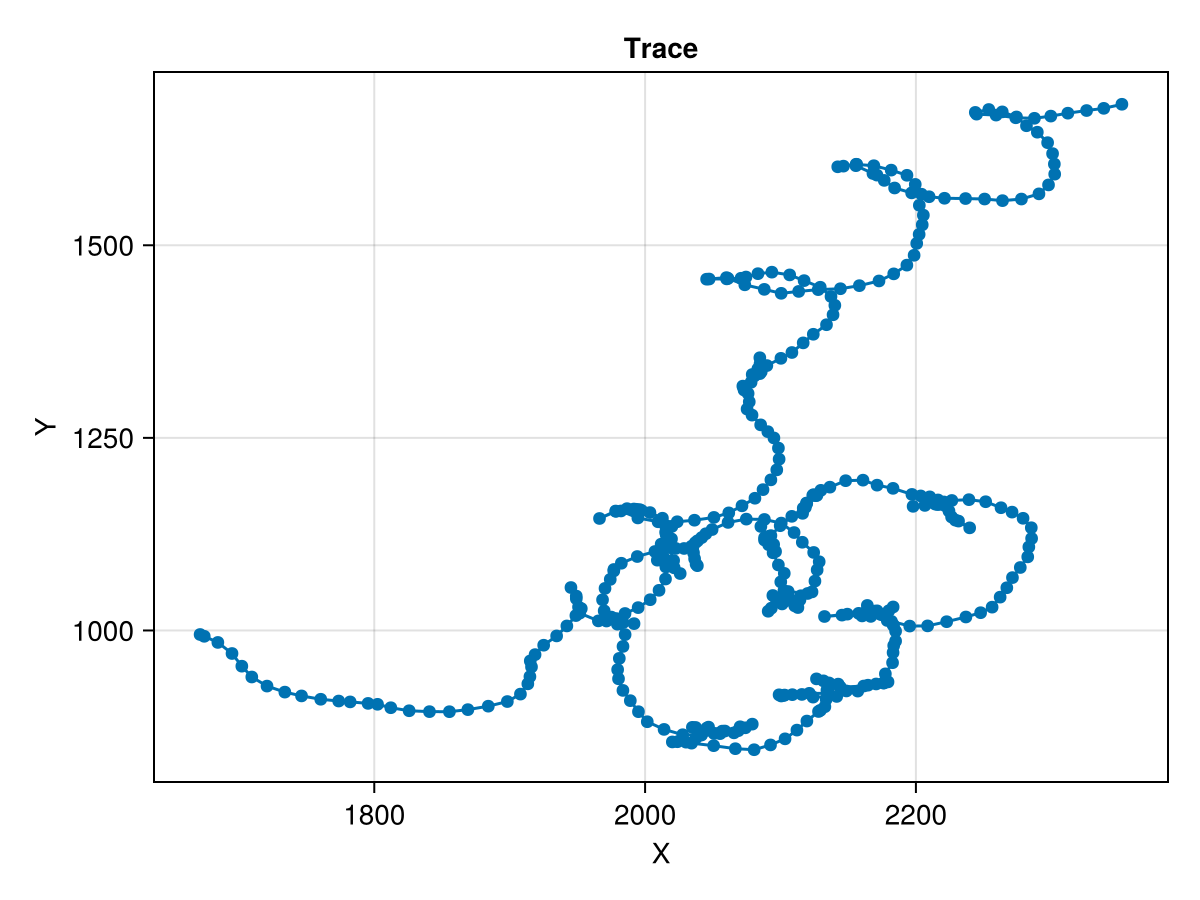

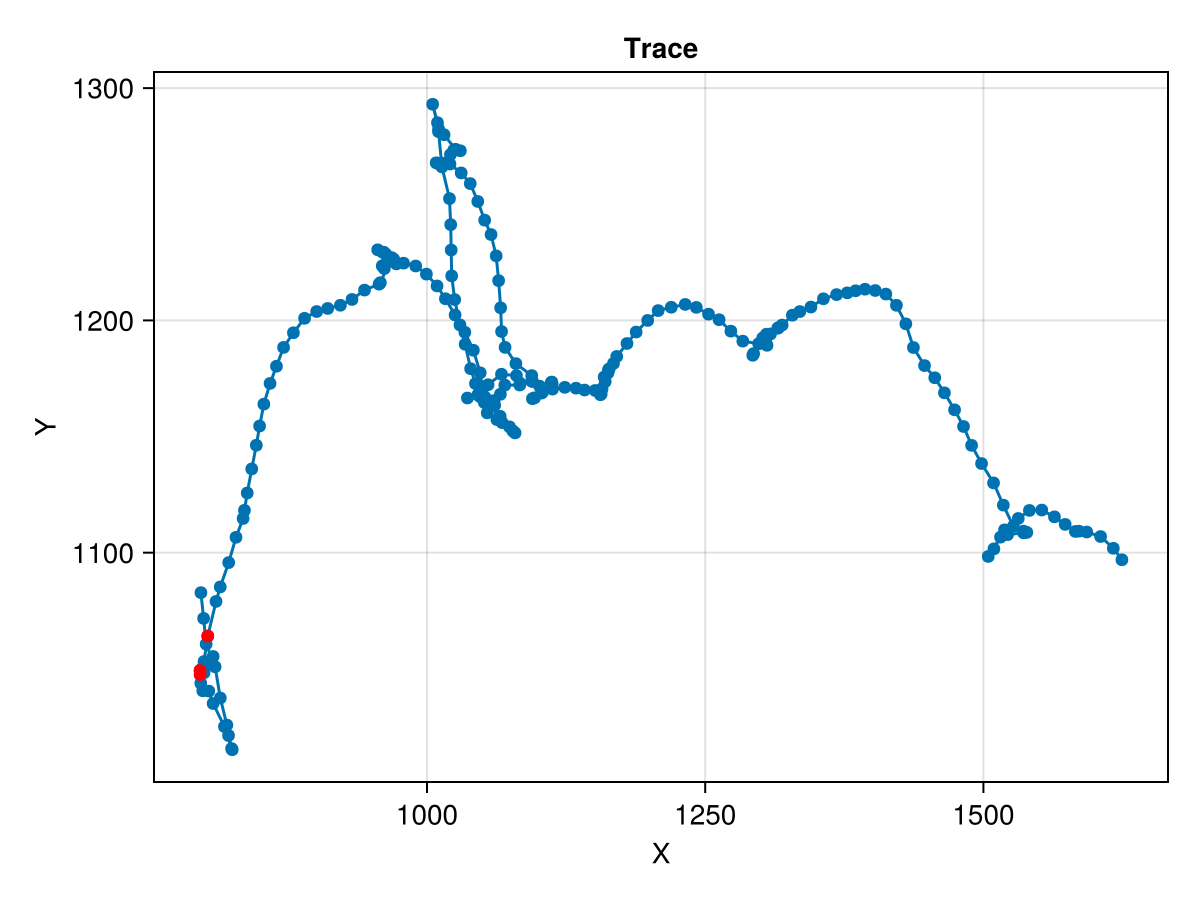

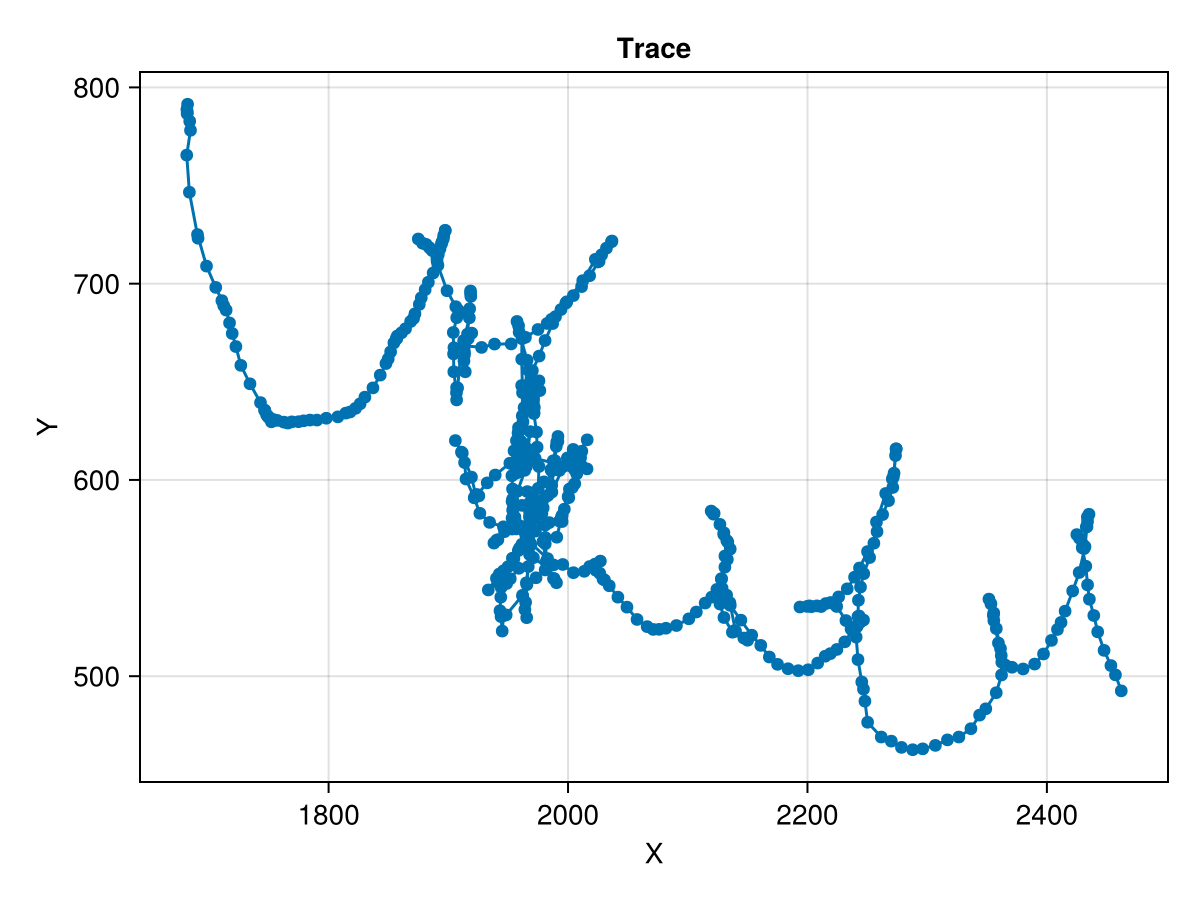

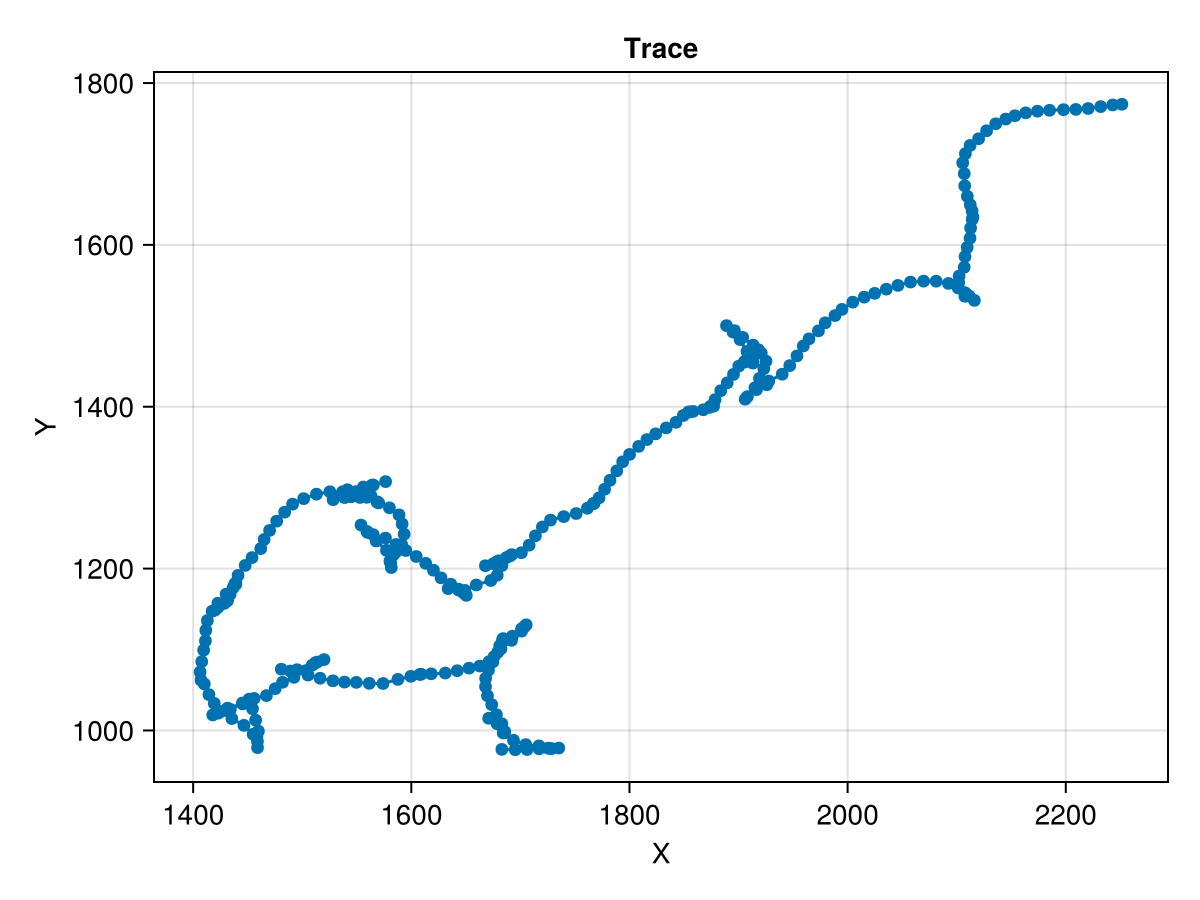

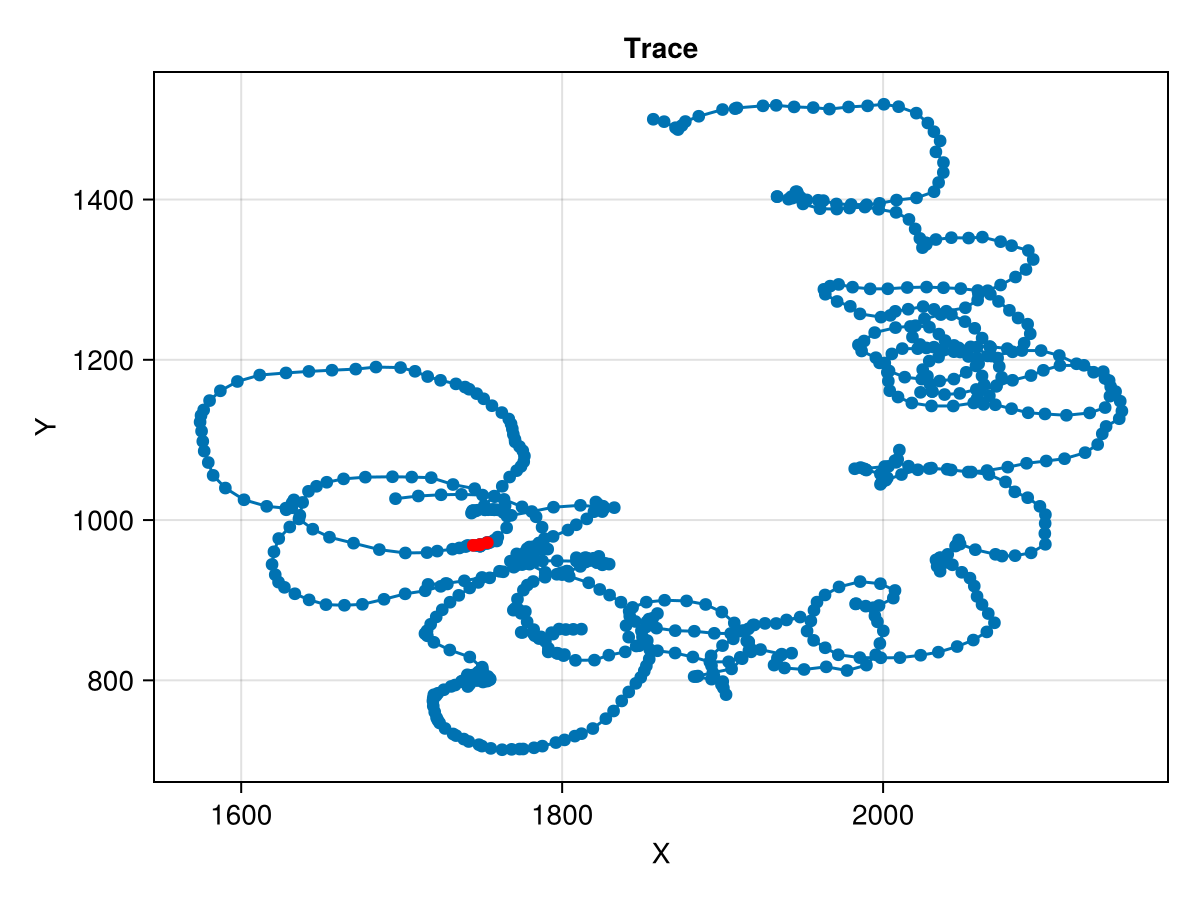

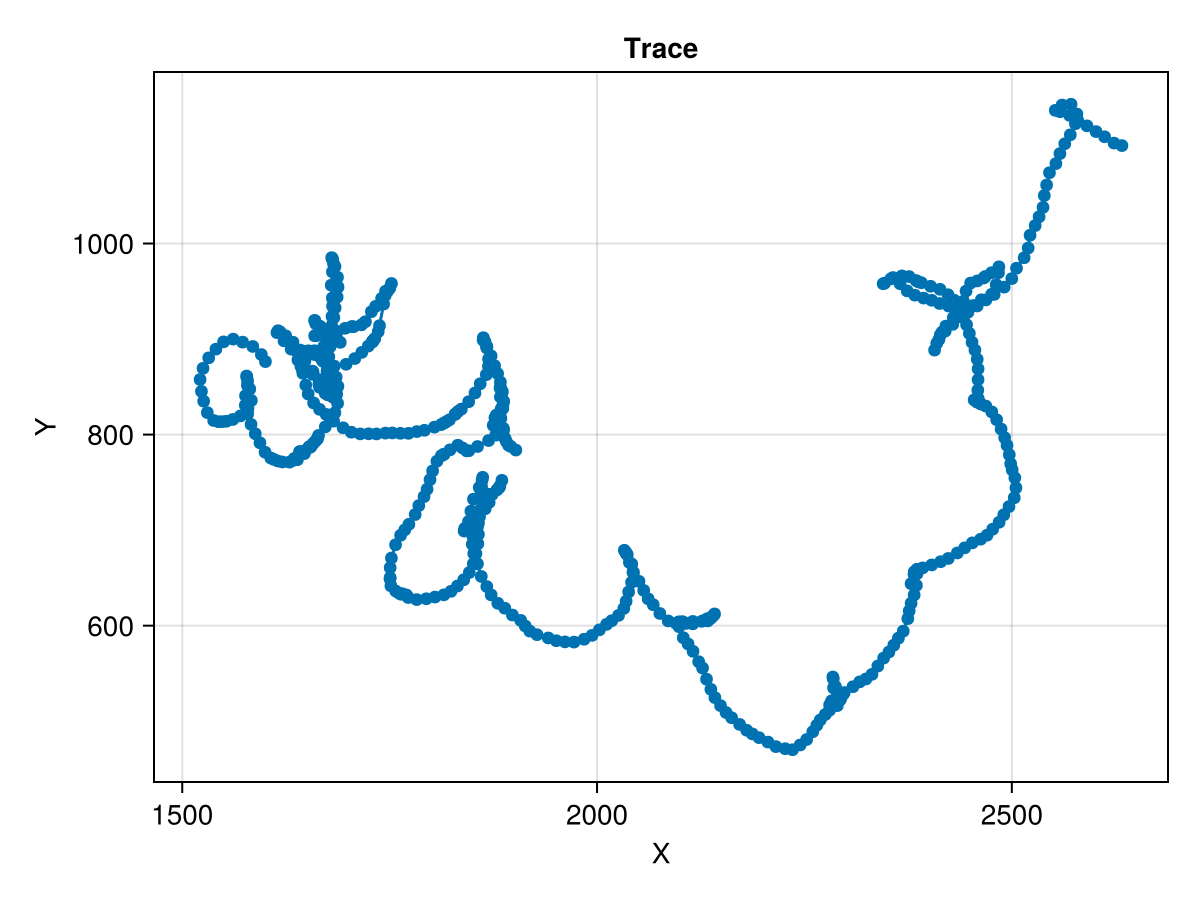

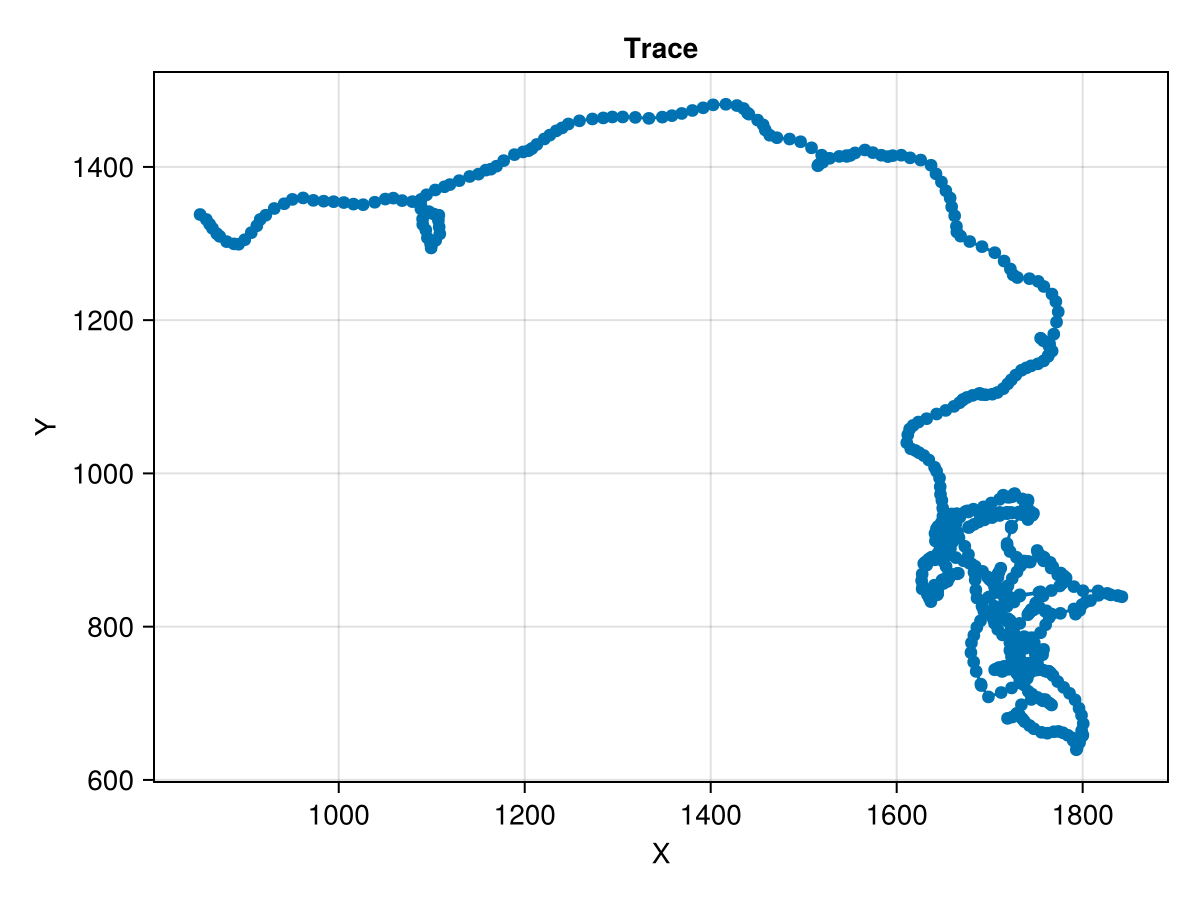

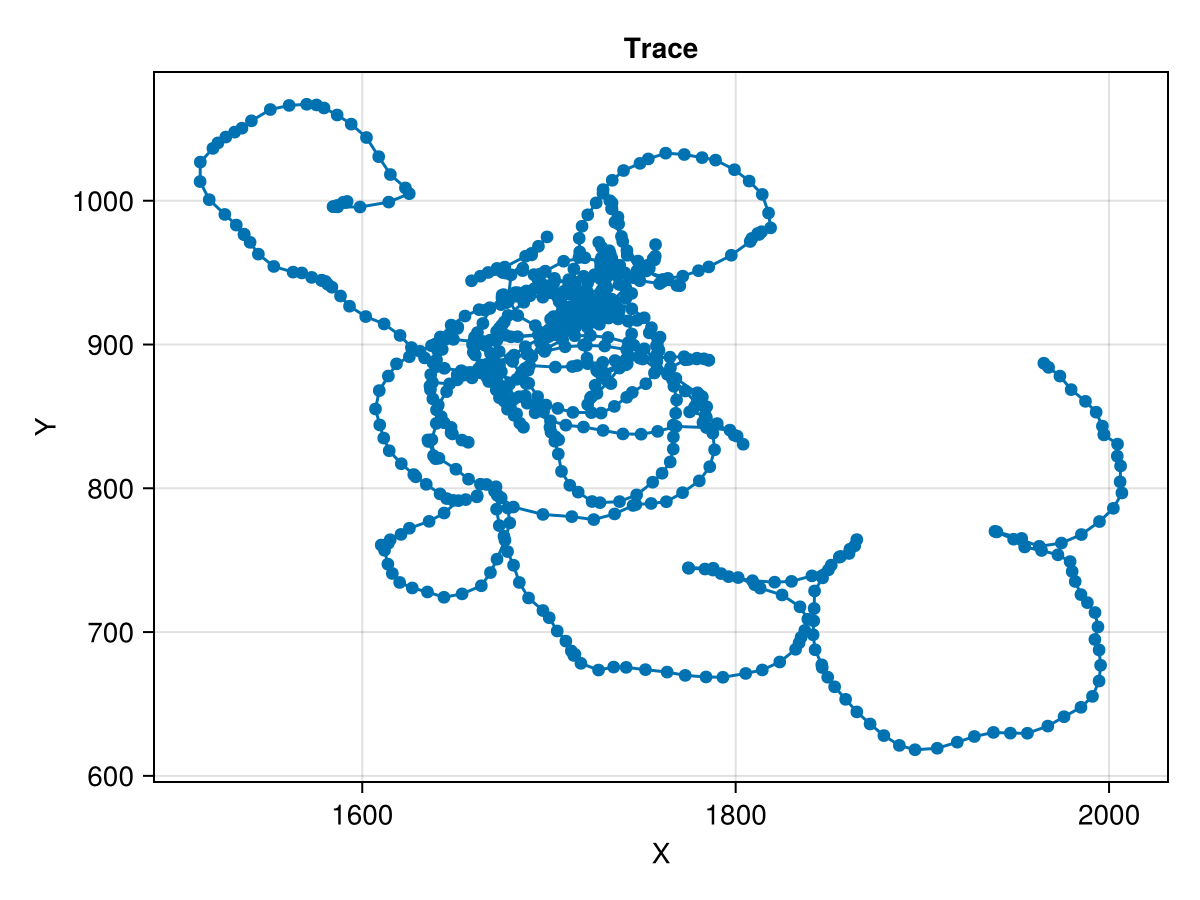

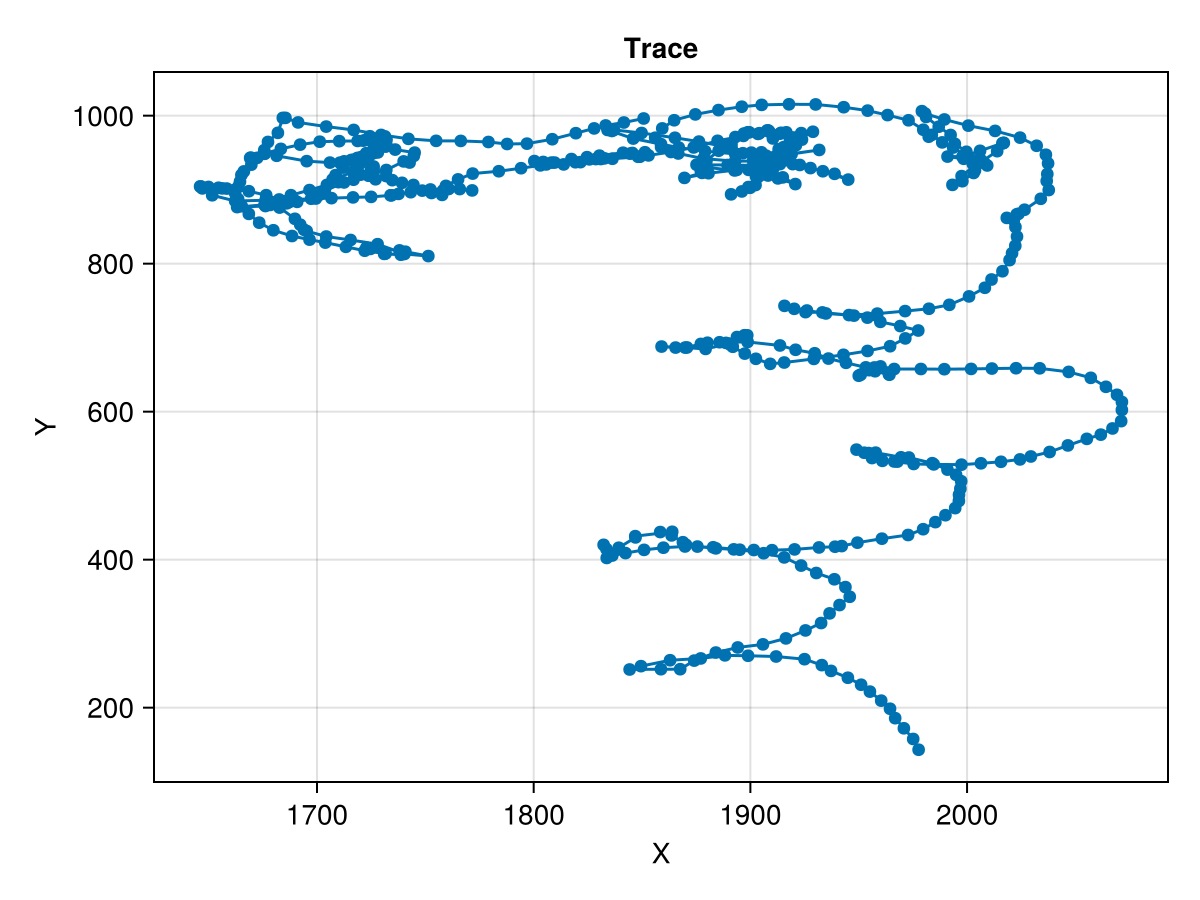

9-element Vector{CairoMakie.Screen{CairoMakie.IMAGE}}:
 CairoMakie.Screen{CairoMakie.IMAGE}(Scene (600px, 450px):
  0 Plots
  1 Child Scene:
    └ Scene (600px, 450px), Cairo.CairoSurfaceImage{ColorTypes.ARGB32}(Ptr{Nothing} @0x0000000353b215a0, 1200.0, 900.0, ColorTypes.ARGB32[ARGB32(1.0N0f8,1.0N0f8,1.0N0f8,1.0N0f8) ARGB32(1.0N0f8,1.0N0f8,1.0N0f8,1.0N0f8) … ARGB32(1.0N0f8,1.0N0f8,1.0N0f8,1.0N0f8) ARGB32(1.0N0f8,1.0N0f8,1.0N0f8,1.0N0f8); ARGB32(1.0N0f8,1.0N0f8,1.0N0f8,1.0N0f8) ARGB32(1.0N0f8,1.0N0f8,1.0N0f8,1.0N0f8) … ARGB32(1.0N0f8,1.0N0f8,1.0N0f8,1.0N0f8) ARGB32(1.0N0f8,1.0N0f8,1.0N0f8,1.0N0f8); … ; ARGB32(1.0N0f8,1.0N0f8,1.0N0f8,1.0N0f8) ARGB32(1.0N0f8,1.0N0f8,1.0N0f8,1.0N0f8) … ARGB32(1.0N0f8,1.0N0f8,1.0N0f8,1.0N0f8) ARGB32(1.0N0f8,1.0N0f8,1.0N0f8,1.0N0f8); ARGB32(1.0N0f8,1.0N0f8,1.0N0f8,1.0N0f8) ARGB32(1.0N0f8,1.0N0f8,1.0N0f8,1.0N0f8) … ARGB32(1.0N0f8,1.0N0f8,1.0N0f8,1.0N0f8) ARGB32(1.0N0f8,1.0N0f8,1.0N0f8,1.0N0f8)]), Cairo.CairoContext(Ptr{Nothing} @0x000000015b0d0000, Cairo.Cair

In [7]:
display.(figs)

# Simple Description

In [34]:
@pipe new_df |> transform!(_, :data => ByRow(x -> split(x, "_")[end]) => :day);
categories = @pipe new_df.type |> Vector{String} |> map(x-> x == "naive" ? 1 : x == "4h" ? 2 : 3,_);
dodge = map(x -> x == "3.14" ? 0 : x == "3.16" ? 1 : x == "3.17" ? 2 : x == "3.18" ? 3 : 4, new_df.day) * 3;

In [35]:
@pipe new_df |> groupby(_, :type) |>
    combine(_,  row -> size(row,1)) |> 
    DataFrames.rename!(_, :type => :group, :x1 => :sample_size) 
    # _[!, :group] = string.(_[:,:group])


Row,group,sample_size
,String7?,Int64
1,naive,93
2,4h,86
3,8h,55


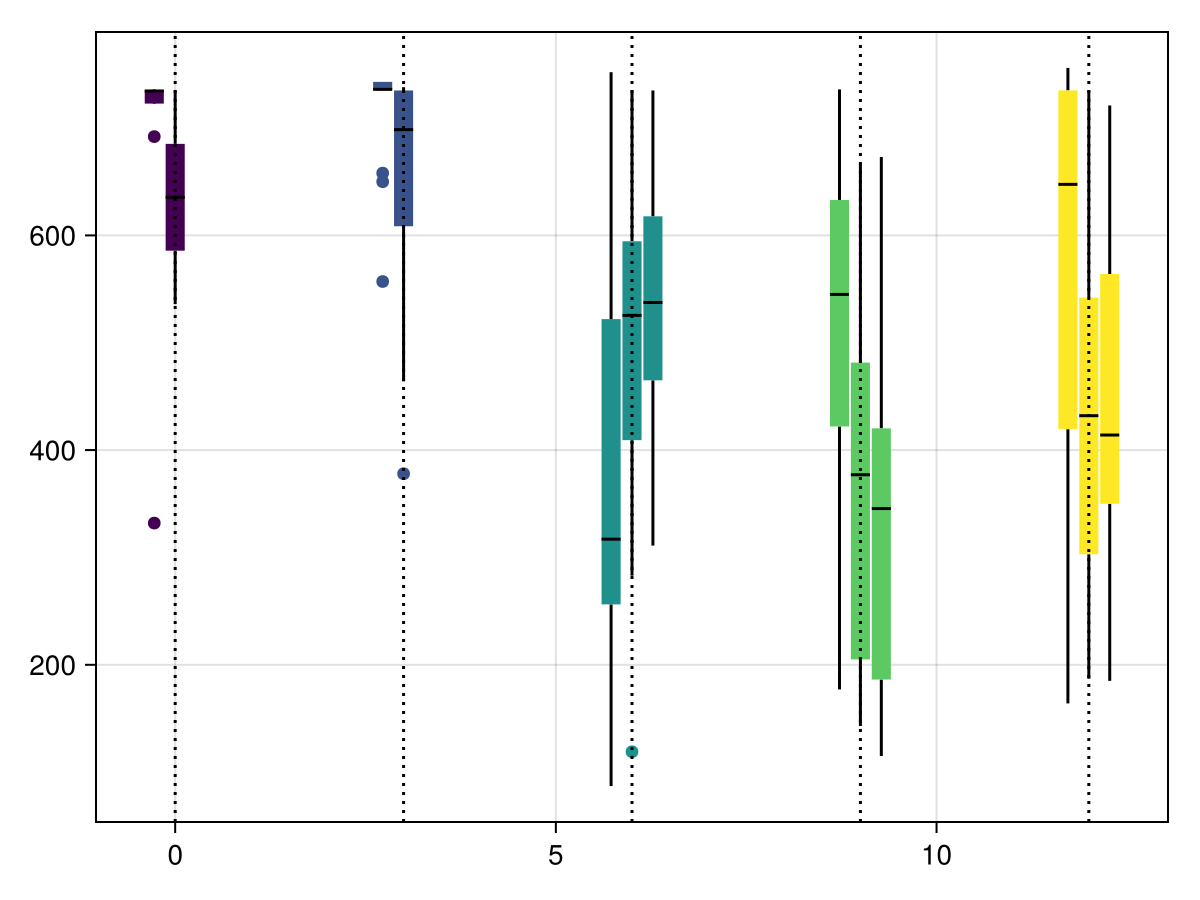

In [36]:
boxplot(dodge, new_df.frames_num, dodge = categories,  color = dodge)
vlines!([0:4...] * 3, linestyle=:dot, color=:black)
current_figure() 

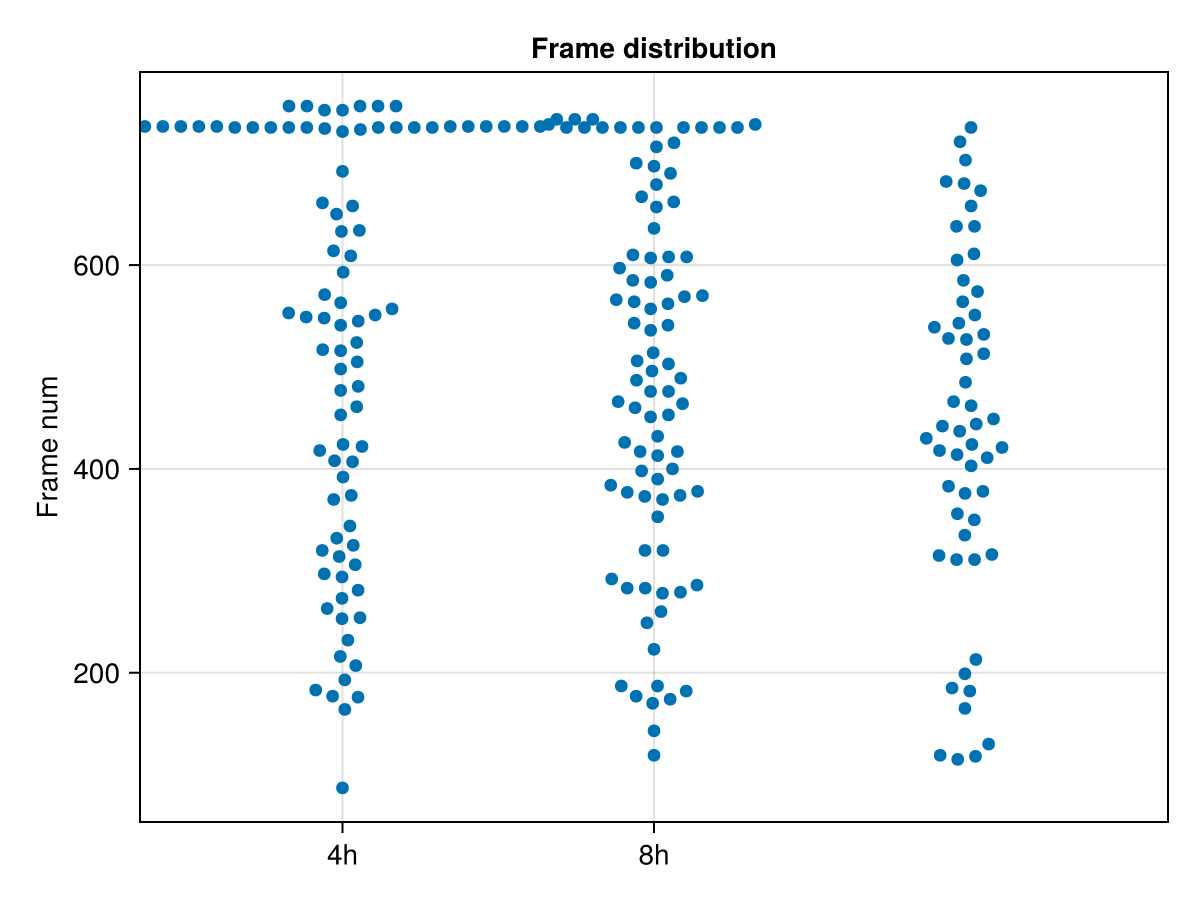

In [37]:
fig = Figure()
ax = Axis(fig[1, 1],
    title = "Frame distribution",
    xticks = ([0,1, 2], ["Naive", "4h", "8h"]),
    ylabel = "Frame num")
beeswarm!(ax,categories , new_df.frames_num )
fig

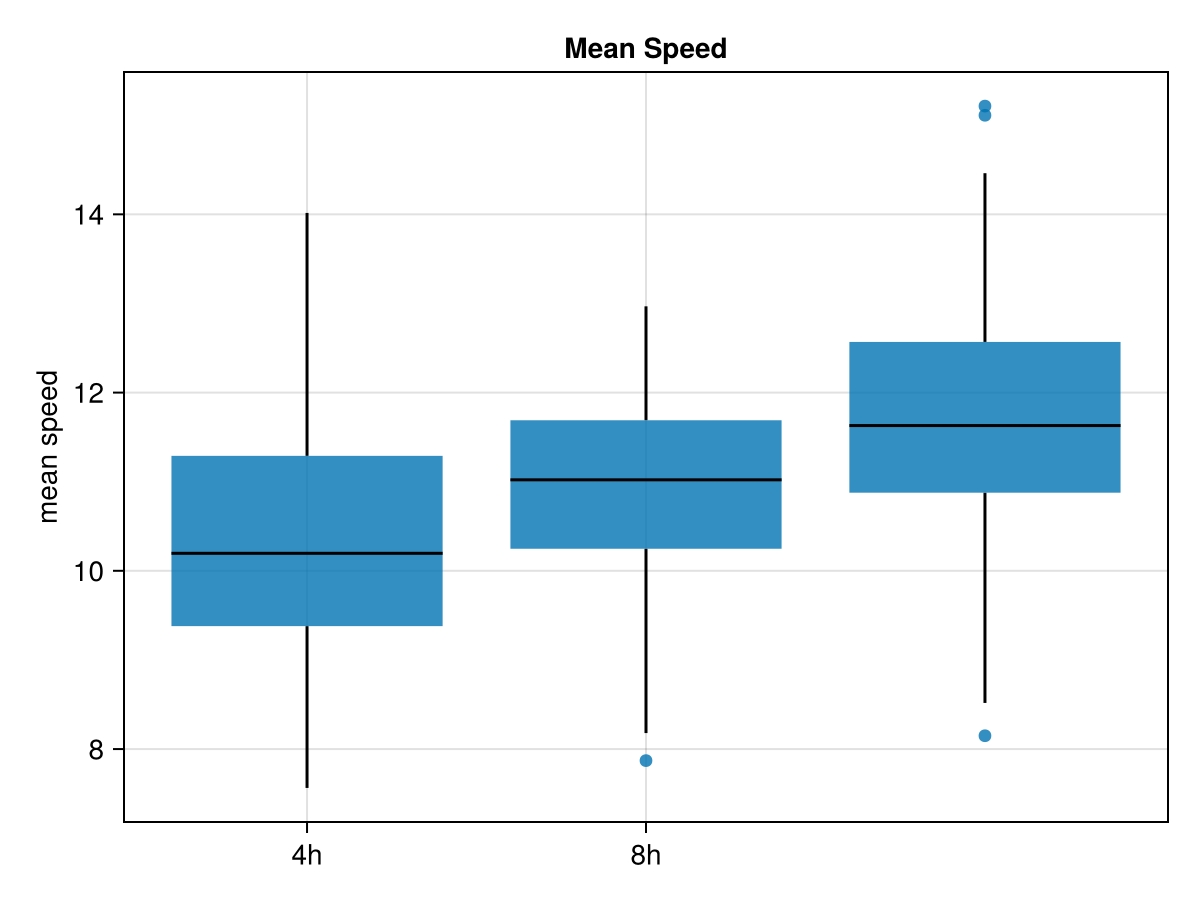

In [38]:
fig = Figure()
ax = Axis(fig[1, 1],
    title = "Mean Speed",
    xticks = ([0,1, 2], ["Naive", "4h", "8h"]),
    ylabel = "mean speed")
boxplot!(ax,categories, new_df.mean_speed)
fig

# KDE

In [39]:
using KernelDensity
all_angles = vcat(new_df.dfs...).angle_deg |> skipmissing |> collect
U = kde(all_angles);
kde_x = 0:1e-3:180 |> collect;
kde_y = pdf(U, kde_x);
threshold = kde_x[argmin(kde_y)]

99.244

In [69]:
CairoMakie.activate!(type="svg")
fig = Figure()
ax = Axis(fig[1, 1],
    title = "Angle distribution",
    xlabel = "Angle (degree)",
    ylabel = "Density")
hist!(ax, all_angles, normalization=:pdf, label="histogram")
lines!(ax, kde_x, kde_y, color = :red, linewidth = 1, linestyle=:dash, label="KDE curve")
vlines!(ax, [threshold], color = :black, linewidth=2, linestyle=:dashdot)
text!(ax, "Threshold", position=Point2f(threshold + 5, 0.02), fontsize=15, color=:gray, align=(:left,:center), font=:bold)
fig[1,2] = Legend(fig, ax)
@pipe fig |> save("angle_distribution.pdf")


CairoMakie.Screen{PDF}


In [41]:
for tmp_df in new_df |> eachrow
    tmp_df.dfs[!, :reorientation] = tmp_df.dfs.angle_deg .> threshold
end


In [42]:
transform!(new_df, :dfs => ByRow(x -> @pipe x[:, :reorientation] |> skipmissing |> collect |> 
    vcat(_, missings(30 * (length(_) ÷ 30 + 1) - length(_))...) |> reshape(_, 30,:) |>
    eachcol |> map(x -> sum(x |> skipmissing), _)
    ) => :count_in_60s)

Row,data,dfs,type,frames_num,mean_speed,day,count_in_60s
,String,DataFrame,String7?,Int64,Float64,SubStrin…,Array…
1,n2_naive4_3.19,164×10 DataFrame,naive,164,11.0179,3.19,"[4, 3, 1, 1, 1, 3]"
2,n2_naive4_3.19,294×10 DataFrame,naive,294,9.58806,3.19,"[4, 5, 1, 4, 0, 1, 2, 5, 2, 0]"
3,n2_naive4_3.19,193×10 DataFrame,naive,193,8.43959,3.19,"[2, 2, 1, 1, 5, 4, 1]"
4,n2_naive4_3.19,253×10 DataFrame,naive,253,7.5776,3.19,"[5, 6, 7, 2, 4, 10, 4, 3, 0]"
5,n2_naive4_3.19,424×10 DataFrame,naive,424,9.70011,3.19,"[8, 3, 3, 5, 2, 4, 6, 1, 3, 3, 2, 1, 1, 4, 0]"
6,n2_naive4_3.19,344×10 DataFrame,naive,344,8.19942,3.19,"[6, 6, 4, 5, 5, 1, 5, 1, 5, 2, 3, 1]"
7,n2_naive4_3.19,418×10 DataFrame,naive,418,9.4812,3.19,"[5, 5, 4, 4, 3, 8, 5, 3, 2, 4, 3, 2, 3, 2]"
8,n2_naive4_3.19,661×10 DataFrame,naive,661,9.6613,3.19,"[4, 3, 6, 5, 6, 4, 2, 4, 4, 3 … 2, 2, 3, 0, 3, 0, 3, 3, 4, 1]"
9,n2_naive4_3.17,408×10 DataFrame,naive,408,11.6503,3.17,"[0, 4, 5, 7, 7, 4, 6, 5, 4, 5, 6, 1, 2, 0]"


In [43]:
new_count_df = DataFrame(:subjs => String[], [Symbol(string(i) * "min") => Union{Int64, Missing}[] for i in 1:26]...)

for i in eachrow(new_df)
    tmp_counts = vcat(i.count_in_60s, missings(26 - length(i.count_in_60s))...)
    push!(new_count_df, (i.data, tmp_counts...))
end
leftjoin!(new_count_df, subjs_type_df, on = :subjs => :subjs)

Row,subjs,1min,2min,3min,4min,5min,6min,7min,8min,9min,10min,11min,12min,13min,14min,15min,16min,17min,18min,19min,20min,21min,22min,23min,24min,25min,26min,type
,String,Int64?,Int64?,Int64?,Int64?,Int64?,Int64?,Int64?,Int64?,Int64?,Int64?,Int64?,Int64?,Int64?,Int64?,Int64?,Int64?,Int64?,Int64?,Int64?,Int64?,Int64?,Int64?,Int64?,Int64?,Int64?,Int64?,String7?
1,n2_naive4_3.19,4,3,1,1,1,3,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,naive
2,n2_naive4_3.19,4,5,1,4,0,1,2,5,2,0,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,naive
3,n2_naive4_3.19,2,2,1,1,5,4,1,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,naive
4,n2_naive4_3.19,5,6,7,2,4,10,4,3,0,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,naive
5,n2_naive4_3.19,8,3,3,5,2,4,6,1,3,3,2,1,1,4,0,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,naive
6,n2_naive4_3.19,6,6,4,5,5,1,5,1,5,2,3,1,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,naive
7,n2_naive4_3.19,5,5,4,4,3,8,5,3,2,4,3,2,3,2,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,naive
8,n2_naive4_3.19,4,3,6,5,6,4,2,4,4,3,7,5,2,2,3,0,3,0,3,3,4,1,missing,missing,missing,missing,naive
9,n2_naive4_3.17,0,4,5,7,7,4,6,5,4,5,6,1,2,0,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,naive


In [44]:
naive_reorientation = @pipe new_count_df |> filter(:type => ==("naive")) |> select(_, Not([:type, :subjs])) |> Matrix |>
    eachcol |> map(x -> [mean(x|>skipmissing), std(x|>skipmissing), 1 .- ismissing.(x) |> sum], _)
train_4h_reorientation = @pipe new_count_df |> filter(:type => ==("4h")) |> select(_, Not([:type, :subjs])) |> Matrix |>
    eachcol |> map(x -> [mean(x|>skipmissing), std(x|>skipmissing), 1 .- ismissing.(x) |> sum], _)
train_8h_reorientation = @pipe new_count_df |> filter(:type => ==("8h")) |> select(_, Not([:type, :subjs])) |> Matrix |>
    eachcol |> map(x -> [mean(x|>skipmissing), std(x|>skipmissing), 1 .- ismissing.(x) |> sum], _);

In [58]:
sum((@pipe train_8h_reorientation |> hcat(_...)[3,:]) .> 30 )

15

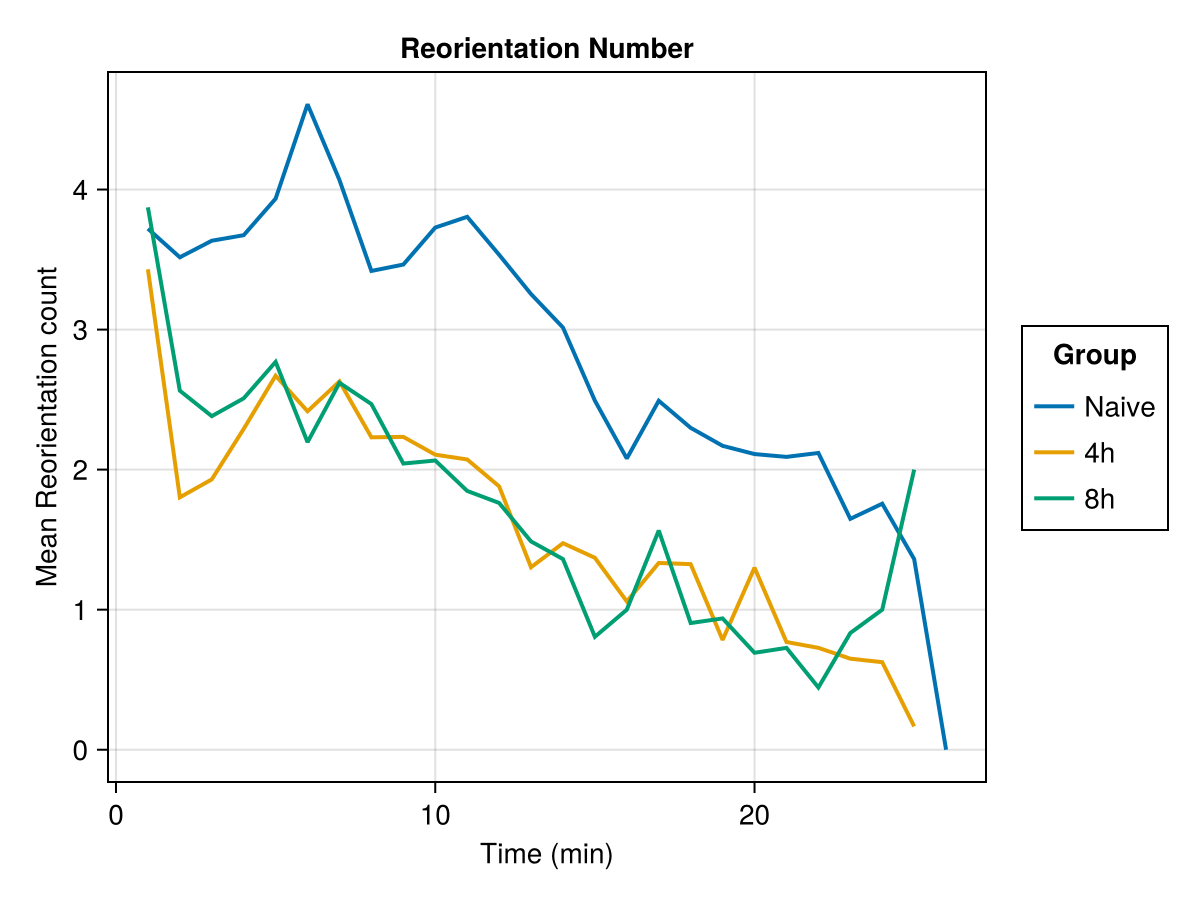

In [45]:
fig = Figure()
ax = Axis(fig[1, 1],
    title = "Reorientation Number",
    xlabel = "Time (min)",
    ylabel = "Mean Reorientation count")

lines!(ax, 1:26, hcat(naive_reorientation...)[1, :] , label="Naive", linewidth=2)
lines!(ax, 1:26, hcat(train_4h_reorientation...)[1, :] ,  label="4h", linewidth=2)
lines!(ax, 1:26, hcat(train_8h_reorientation...)[1, :] ,  label="8h", linewidth=2)
fig[1,2] = Legend(fig, ax, "Group")
fig



In [46]:
naive_reorientation2 = @pipe new_count_df |> filter(:type => ==("naive")) |> select(_, Not([:type, :subjs])) |> Matrix |> replace(_, missing => 0) |>
        eachcol |> map(x -> [mean(x |> skipmissing), std(x |> skipmissing), length(x |> skipmissing |> collect)], _)  |> hcat(_...)'
train_4h_reorientation2 = @pipe new_count_df |> filter(:type => ==("4h")) |> select(_, Not([:type, :subjs])) |> Matrix |> replace(_, missing => 0) |>
        eachcol |> map(x -> [mean(x |> skipmissing), std(x |> skipmissing), length(x |> skipmissing |> collect)], _)  |> hcat(_...)'
train_8h_reorientation2 = @pipe new_count_df |> filter(:type => ==("8h")) |> select(_, Not([:type, :subjs])) |> Matrix |> replace(_, missing => 0) |>
        eachcol |> map(x -> [mean(x |> skipmissing), std(x |> skipmissing), length(x |> skipmissing |> collect)], _)  |> hcat(_...)'

mean_naive, std_naive, n_naive = @pipe naive_reorientation2[:,1], naive_reorientation2[:,2], naive_reorientation2[:,3]
mean_4h, std_4h, n_4h = @pipe train_4h_reorientation2[:,1], train_4h_reorientation2[:,2], train_4h_reorientation2[:,3]
mean_8h, std_8h, n_8h = @pipe train_8h_reorientation2[:,1], train_8h_reorientation2[:,2], train_8h_reorientation2[:,3]

([3.8727272727272726, 2.5636363636363635, 2.381818181818182, 2.5090909090909093, 2.618181818181818, 2.036363636363636, 2.381818181818182, 2.109090909090909, 1.709090909090909, 1.7272727272727273  …  0.6545454545454545, 0.34545454545454546, 0.2727272727272727, 0.16363636363636364, 0.14545454545454545, 0.07272727272727272, 0.09090909090909091, 0.05454545454545454, 0.03636363636363636, 0.0], [2.6531221681364845, 1.9222251415870866, 1.8103704254768076, 1.7624974628059202, 1.638550726968343, 1.2760418599257737, 1.9195959170743424, 1.6063845680506832, 1.2571680000983878, 1.5806063704529656  …  1.0923671513122286, 0.6996872798345627, 0.6222582962125833, 0.4620259878708269, 0.4045199174779453, 0.2620817977022988, 0.4819992036541475, 0.29926959344759624, 0.2696799449852968, 0.0], [55.0, 55.0, 55.0, 55.0, 55.0, 55.0, 55.0, 55.0, 55.0, 55.0  …  55.0, 55.0, 55.0, 55.0, 55.0, 55.0, 55.0, 55.0, 55.0, 55.0])

$$
\text{S.E.} = \frac{\sigma}{\sqrt{N}}
$$

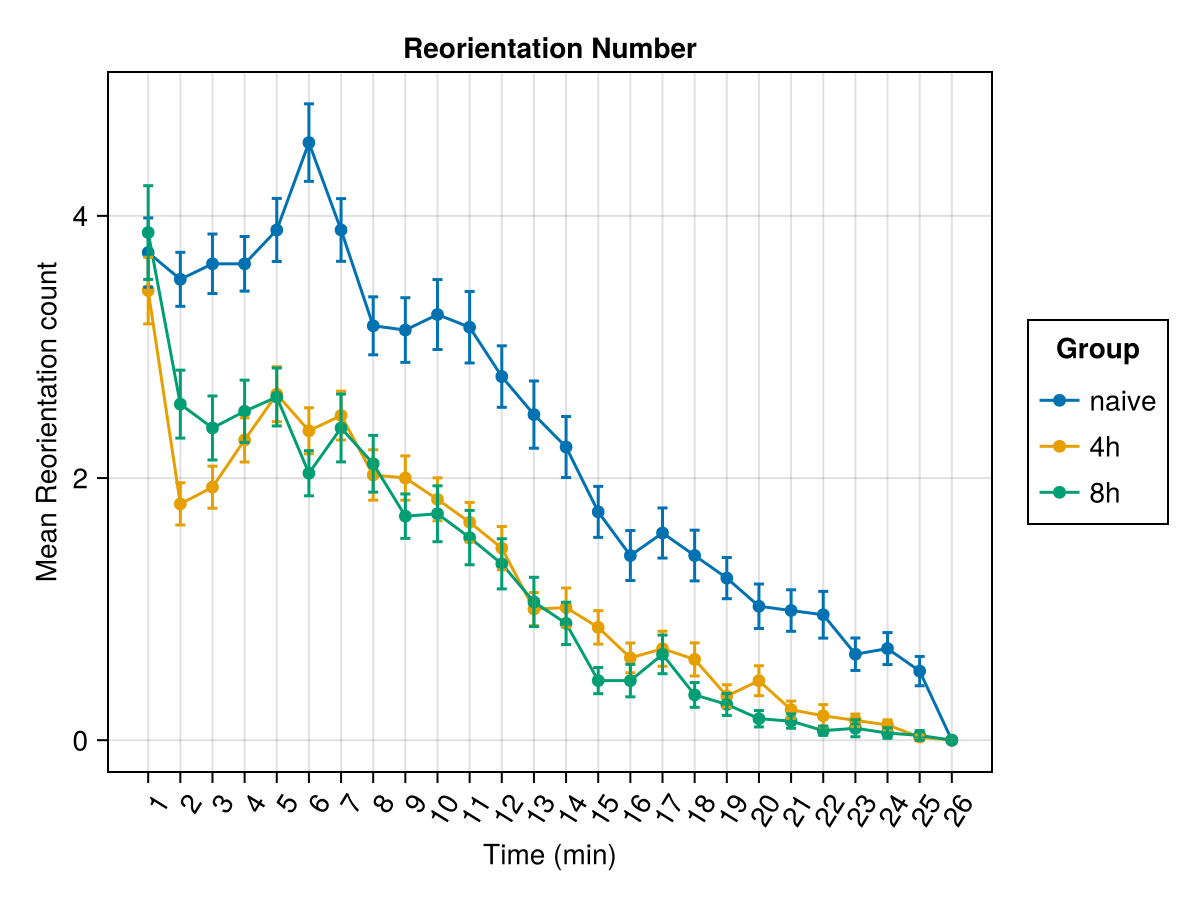

In [47]:
fig2 = Figure()
ax = Axis(fig2[1, 1],
    title = "Reorientation Number",
    xlabel = "Time (min)",
    ylabel = "Mean Reorientation count",
    xticklabelrotation = 45,
    xticks = (1:26))

scatterlines!(ax, mean_naive, label="naive")
scatterlines!(ax, mean_4h, label="4h")
scatterlines!(ax, mean_8h, label="8h")
errorbars!(ax, 1:26, mean_naive, [std_naive ./ sqrt.(n_naive) for _ in 1:2]...,  whiskerwidth = 5)
errorbars!(ax, 1:26, mean_4h, [std_4h ./ sqrt.(n_4h) for _ in 1:2]...,  whiskerwidth = 5)
errorbars!(ax, 1:26, mean_8h, [std_8h ./ sqrt.(n_8h) for _ in 1:2]...,  whiskerwidth = 5)
fig2[1,2] = Legend(fig2, ax, "Group")

fig2

In [24]:
length.(new_df.count_in_60s) |> maximum

26

In [25]:
t_df = new_df[1, :dfs]
@pipe t_df[:, :reorientation] |> skipmissing |> collect |>  vcat(_,missings(30 * (length(_) ÷ 30 + 1) - length(_))...) |> reshape(_, 30, :) |>
    map(x -> x |> skipmissing |> sum, eachcol(_))

6-element Vector{Int64}:
 4
 3
 1
 1
 1
 3

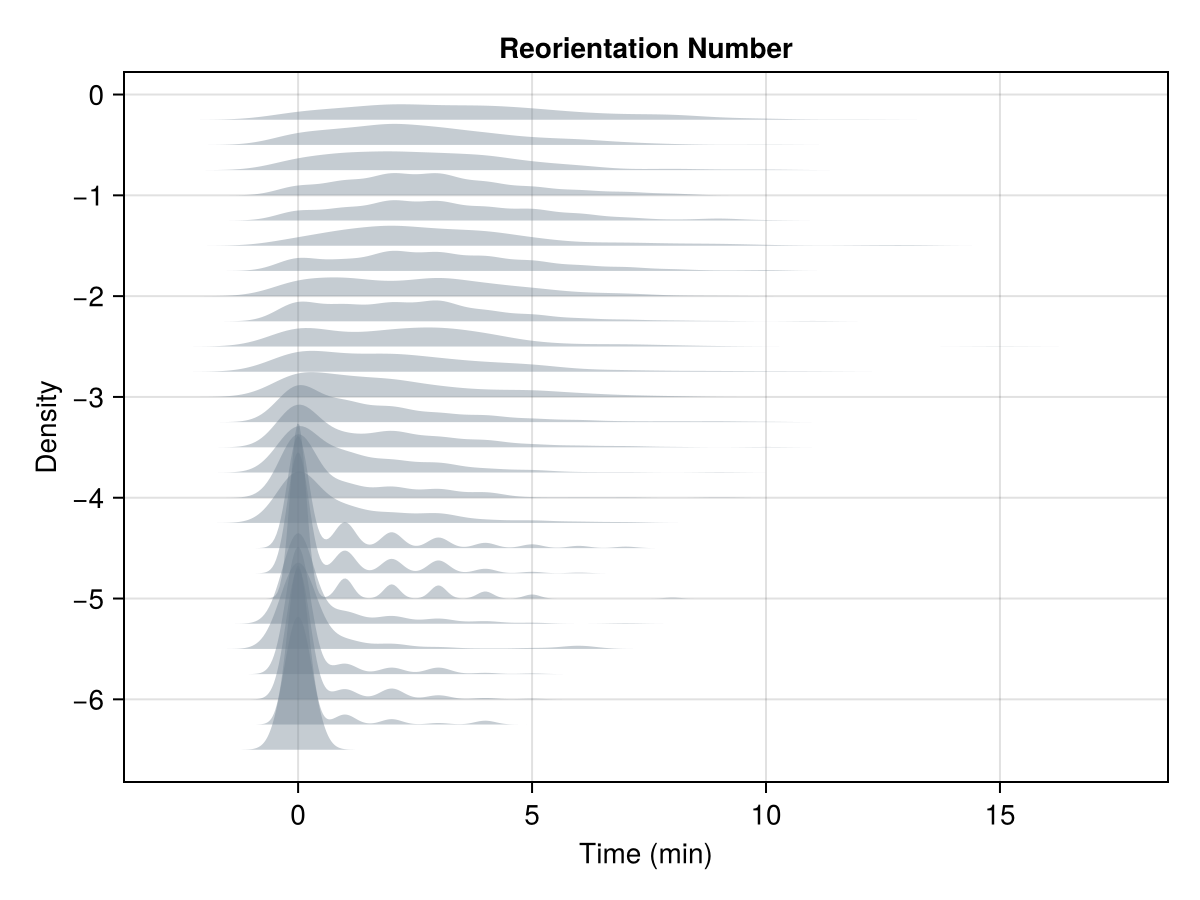

In [27]:
# @pipe new_count_df[:, "11min"] |> density(replace(_,missing => 0))
fig = Figure()
ax = Axis(fig[1, 1],
    title = "Reorientation Number",
    xlabel = "Time (min)",
    ylabel = "Density")
for (i, vector) in enumerate(@pipe new_count_df |> select(_, Not([:type, :subjs])) |> Matrix |> eachcol)
    tmp_vec = @pipe vector |> replace(_, missing => 0) 
    
    # @show tmp_vec
    density!(ax,tmp_vec, offset = -i/4, color = (:slategray, 0.4))
    
end
fig

# Hypothesis Test

In [28]:
all_speed = @pipe new_df |> groupby(_, :type) |> collect |> map(x -> x.mean_speed, _)
OneWayANOVATest(all_speed[:]...)

One-way analysis of variance (ANOVA) test
-----------------------------------------
Population details:
    parameter of interest:   Means
    value under h_0:         "all equal"
    point estimate:          NaN

Test summary:
    outcome with 95% confidence: reject h_0
    p-value:                     <1e-08

Details:
    number of observations: [93, 86, 55]
    F statistic:            20.3123
    degrees of freedom:     (2, 231)


In [29]:
naive_df, train_4h_df, train_8h_df =  @pipe new_count_df |> groupby(_, :type) |> collect |> map(x -> select(x, Not([:type, :subjs])), _)
naive_m, train_4h_m, train_8h_m = map(x -> replace(x, missing => 0), [Matrix(naive_df), Matrix(train_4h_df), Matrix(train_8h_df)])
# train
# 
for i in 1:26
    tmp_p = OneWayANOVATest(naive_m[:,i], train_4h_m[:,i], train_8h_m[:,i])  |> pvalue
    if tmp_p < 0.05
        println("pvalue: ", round(tmp_p; digits = 3), " at ", i, " min.")
    else
        println("pvalue: ", round(tmp_p; digits = 3), " at ", i, " min. Not significant.")
    end
end

# OneWayANOVATest(naive_m[:,2], train_4h_m[:,2], train_8h_m[:,2])
# OneWayANOVATest(naive_m[:,2], train_4h_m[:,2], train_8h_m[:,2])

pvalue: 0.552 at 1 min. Not significant.
pvalue: 0.0 at 2 min.
pvalue: 0.0 at 3 min.
pvalue: 0.0 at 4 min.
pvalue: 0.0 at 5 min.
pvalue: 0.0 at 6 min.
pvalue: 0.0 at 7 min.
pvalue: 0.0 at 8 min.
pvalue: 0.0 at 9 min.
pvalue: 0.0 at 10 min.
pvalue: 0.0 at 11 min.
pvalue: 0.0 at 12 min.
pvalue: 0.0 at 13 min.
pvalue: 0.0 at 14 min.
pvalue: 0.0 at 15 min.
pvalue: 0.0 at 16 min.
pvalue: 0.0 at 17 min.
pvalue: 0.0 at 18 min.
pvalue: 0.0 at 19 min.
pvalue: 0.0 at 20 min.
pvalue: 0.0 at 21 min.
pvalue: 0.0 at 22 min.
pvalue: 0.0 at 23 min.
pvalue: 0.0 at 24 min.
pvalue: 0.0 at 25 min.
pvalue: NaN at 26 min. Not significant.


In [30]:
for i in 1:26
    tmp_p = OneWayANOVATest(train_4h_m[:,i], train_8h_m[:,i])  |> pvalue
    if tmp_p < 0.05
        println("pvalue: ", round(tmp_p; digits = 3), " at ", i, " min.")
    else
        println("pvalue: ", round(tmp_p; digits = 3), " at ", i, " min. Not significant.")
    end
end

pvalue: 0.291 at 1 min. Not significant.
pvalue: 0.008 at 2 min.
pvalue: 0.1 at 3 min. Not significant.
pvalue: 0.432 at 4 min. Not significant.
pvalue: 0.945 at 5 min. Not significant.
pvalue: 0.202 at 6 min. Not significant.
pvalue: 0.755 at 7 min. Not significant.
pvalue: 0.767 at 8 min. Not significant.
pvalue: 0.236 at 9 min. Not significant.
pvalue: 0.673 at 10 min. Not significant.
pvalue: 0.633 at 11 min. Not significant.
pvalue: 0.634 at 12 min. Not significant.
pvalue: 0.798 at 13 min. Not significant.
pvalue: 0.587 at 14 min. Not significant.
pvalue: 0.021 at 15 min.
pvalue: 0.306 at 16 min. Not significant.
pvalue: 0.829 at 17 min. Not significant.
pvalue: 0.115 at 18 min. Not significant.
pvalue: 0.601 at 19 min. Not significant.
pvalue: 0.052 at 20 min. Not significant.
pvalue: 0.338 at 21 min. Not significant.
pvalue: 0.294 at 22 min. Not significant.
pvalue: 0.439 at 23 min. Not significant.
pvalue: 0.277 at 24 min. Not significant.
pvalue: 0.706 at 25 min. Not signific